In [1]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
np.random.seed(42)
n = 500

temperature = np.random.normal(75, 5, n)
vibration   = np.random.normal(0.5, 0.1, n)
pressure    = np.random.normal(100, 8, n)

for i in [50, 150, 250, 350, 450]:
    temperature[i] += np.random.uniform(25, 40)
    vibration[i]   += np.random.uniform(0.8, 1.5)
    pressure[i]    -= np.random.uniform(30, 50)

df = pd.DataFrame({
    'timestamp':   pd.date_range('2024-01-01', periods=n, freq='h'),
    'temperature': temperature,
    'vibration':   vibration,
    'pressure':    pressure
})

print(df.head())
print(f"\nDataset shape: {df.shape}")

            timestamp  temperature  vibration    pressure
0 2024-01-01 00:00:00    77.483571   0.592618  111.194843
1 2024-01-01 01:00:00    74.308678   0.690942  107.397069
2 2024-01-01 02:00:00    78.238443   0.360143  100.477043
3 2024-01-01 03:00:00    82.615149   0.556297   94.824506
4 2024-01-01 04:00:00    73.829233   0.434936  105.585787

Dataset shape: (500, 4)


In [3]:
features = ['temperature', 'vibration', 'pressure']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_scaled)

df['anomaly'] = model.predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print(df['anomaly'].value_counts())
print("\nModel training complete!")

anomaly
Normal     475
Anomaly     25
Name: count, dtype: int64

Model training complete!


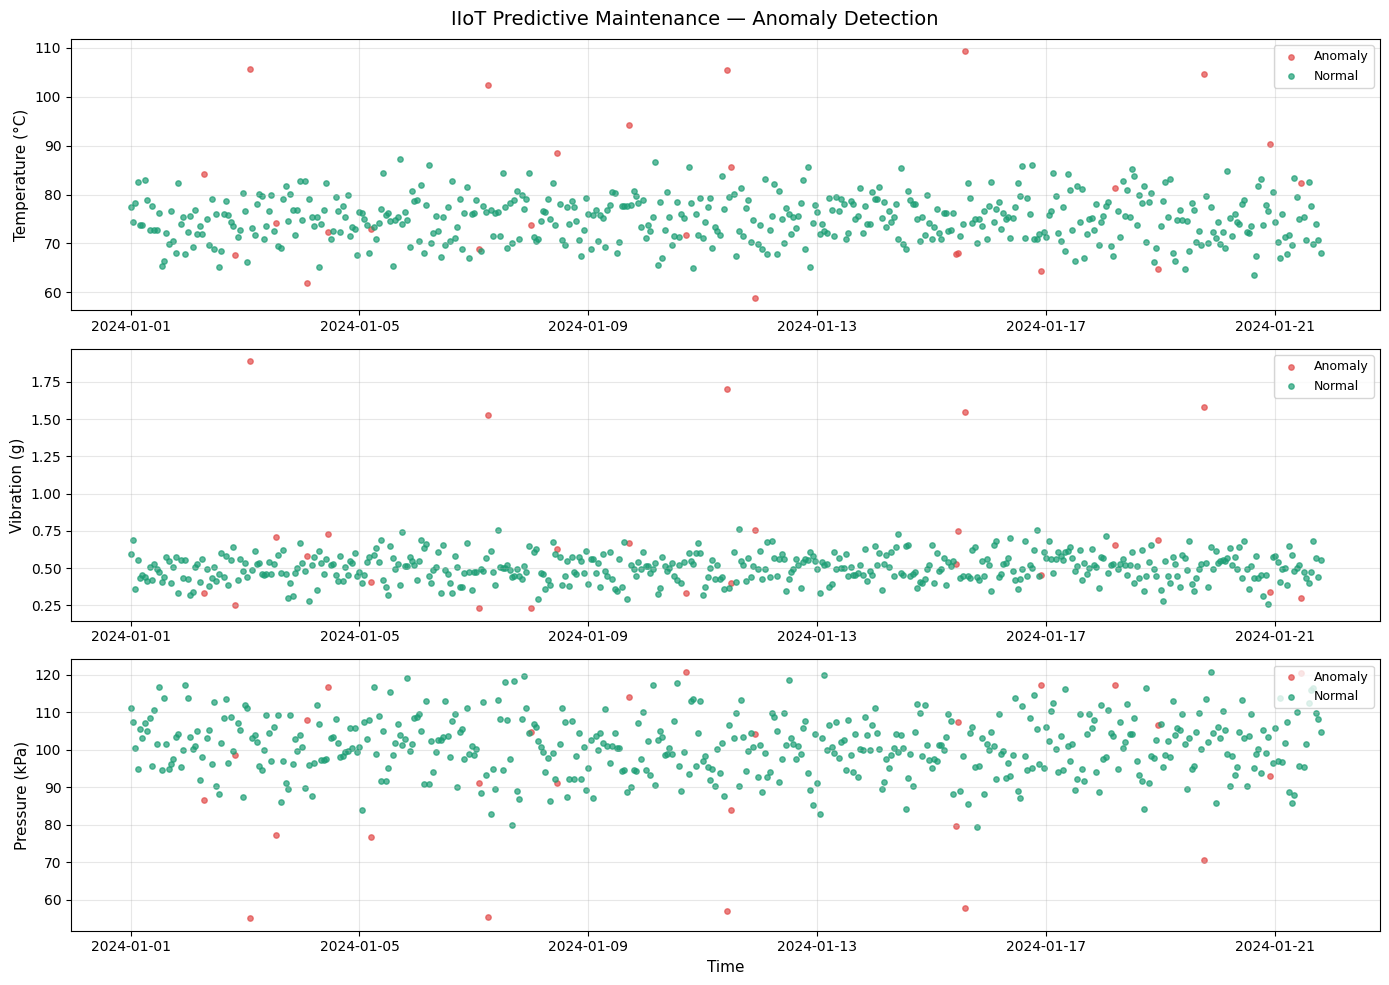

Chart saved as anomaly_detection.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('IIoT Predictive Maintenance — Anomaly Detection', fontsize=14)

sensors = ['temperature', 'vibration', 'pressure']
colors  = {'Normal': '#1D9E75', 'Anomaly': '#E24B4A'}
labels  = ['Temperature (°C)', 'Vibration (g)', 'Pressure (kPa)']

for i, (sensor, label) in enumerate(zip(sensors, labels)):
    for status, grp in df.groupby('anomaly'):
        axes[i].scatter(grp['timestamp'], grp[sensor],
                        c=colors[status], label=status,
                        s=15, alpha=0.7)
    axes[i].set_ylabel(label, fontsize=11)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[2].set_xlabel('Time', fontsize=11)
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as anomaly_detection.png")

In [6]:
total     = len(df)
anomalies = len(df[df['anomaly'] == 'Anomaly'])
normal    = len(df[df['anomaly'] == 'Normal'])

print("=" * 45)
print("   PREDICTIVE MAINTENANCE REPORT")
print("=" * 45)
print(f"  Total readings     : {total}")
print(f"  Normal readings    : {normal}")
print(f"  Anomalies detected : {anomalies}")
print(f"  Anomaly rate       : {anomalies/total*100:.1f}%")
print("=" * 45)
print("\nSensor averages at anomaly points:")
print(df[df['anomaly']=='Anomaly'][['temperature','vibration','pressure']].mean().round(2))

   PREDICTIVE MAINTENANCE REPORT
  Total readings     : 500
  Normal readings    : 475
  Anomalies detected : 25
  Anomaly rate       : 5.0%

Sensor averages at anomaly points:
temperature    80.85
vibration       0.73
pressure       92.45
dtype: float64
